In [1]:
!pip install easyocr
!pip install opencv-python pillow


In [2]:
!pip install openai-whisper

In [3]:
!pip install googletrans==4.0.0rc1

In [4]:
!pip install gTTS

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/VISUAL_ASSISTANCE')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
try:
    from caption_module import generate_caption, unload_caption_model
except:
    generate_caption = None
    unload_caption_model = lambda: None

try:
    from vqa_module import answer_question, unload_model as unload_vqa
except:
    answer_question = None
    unload_vqa = lambda: None

try:
    from ocr_module import extract_text, unload_ocr
except:
    extract_text = None
    unload_ocr = lambda: None

try:
    from object_module import run_yolo, unload_yolo
except:
    run_yolo = None
    unload_yolo = lambda: None

try:
    from color_module import detect_color
except:
    detect_color = None

try:
    from currency_module import identify_currency, unload_currency_model
except:
    identify_currency = None
    unload_currency_model = lambda: None


In [7]:
import torch
import whisper
from googletrans import Translator
from gtts import gTTS
from IPython.display import Audio, display
from PIL import Image

whisper_model = whisper.load_model("medium")
translator = Translator()

def speech_to_text(audio_path):
    result = whisper_model.transcribe(audio_path)
    return result["text"], result["language"]

def translate_to_english(text, src_lang):
    if src_lang == "en": return text
    return translator.translate(text, dest="en").text

def translate_back(text, target_lang):
    if target_lang == "en": return text
    return translator.translate(text, dest=target_lang).text

def speak(text, lang, filename="answer_audio.mp3"):
    tts = gTTS(text, lang=lang)
    tts.save(filename)
    display(Audio(filename, autoplay=True))


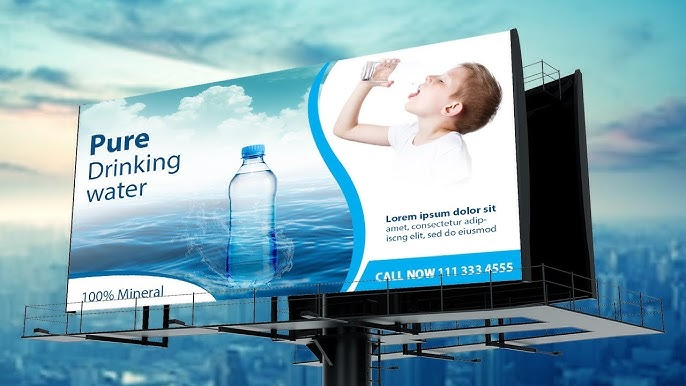

In [8]:
from PIL import Image
from IPython.display import display

image_path = "/content/drive/MyDrive/VISUAL_ASSISTANCE/recordings/ocr_image1.jpg"

image = Image.open(image_path)

display(image)




In [9]:
def route(question_en):
    q = question_en.lower()

    if "color" in q or "colour" in q:
        return "color"

    if any(x in q for x in ["read", "text", "written", "sign", "board"]):
        return "ocr"

    if any(x in q for x in ["where", "which", "find", "locate"]):
        return "object"

    if any(x in q for x in ["note", "rupee", "₹", "currency"]):
        return "currency"

    if any(x in q for x in ["describe", "caption", "tell me about"]):
        return "caption"

    return "vqa"


In [10]:
def get_audio_path(path):
    print("Using audio file:", path)
    return path


In [11]:
import numpy as np

def visual_assistant(image, seconds=6):
    # 1) Record audio
    audio_path = get_audio_path("/content/drive/MyDrive/VISUAL_ASSISTANCE/recordings/ocr_audio.wav")



    # 2) STT
    original_question, detected_language = speech_to_text(audio_path)
    print("You said:", original_question)
    print("Language:", detected_language)

    # 3) Translate to English
    english_question = translate_to_english(original_question, detected_language)
    print("English question:", english_question)

    # 4) Choose module
    module = route(english_question)
    print("Selected module:", module)

    # 5) Ensure image is numpy
    if isinstance(image, Image.Image):
        img_np = np.array(image)[:, :, ::-1]  # BGR
    else:
        img_np = image

    # 6) Run correct module
    if module == "caption":
        answer_en = generate_caption(image)

    elif module == "vqa":
        answer_en = answer_question(image, english_question)

    elif module == "ocr":
        answer_en = extract_text(img_np)

    elif module == "object":
        answer_en = run_yolo(img_np)

    elif module == "color":
        answer_en = detect_color(img_np)

    elif module == "currency":
        label, conf = identify_currency(img_np)
        answer_en = f"This appears to be {label} with confidence {conf:.2f}"

    else:
        answer_en = "Sorry, I cannot process this question."

    print("Answer (EN):", answer_en)

    # 7) Translate back
    final_answer = translate_back(answer_en, detected_language)
    print("Final Answer:", final_answer)

    # 8) Speak
    speak(final_answer, detected_language)

    # 9) Unload heavy modules
    unload_vqa()
    unload_yolo()
    unload_ocr()
    unload_currency_model()
    unload_caption_model()

    return final_answer


In [12]:
visual_assistant(image, seconds = 10)


Using audio file: /content/drive/MyDrive/VISUAL_ASSISTANCE/recordings/ocr_audio.wav


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


You said:  इस तस्वीर में क्या लिखा दिख रहा है?
Language: hi
English question: What is seen written in this picture?
Selected module: ocr
[ocr_module] Loading EasyOCR reader...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Answer (EN): Pure Drinking ipsum dolor sit 3d,cOn, sed dc eiusmad inny CALL Now 111.3324555 10026 Mineral water Lorrin consetietu aip
Final Answer: प्योर ड्रिंकिंग आईपीसम डोलर सिट 3डी, कॉन, सेड डीसी ईआईयूएसएम इनी कॉल अभी 111.3324555 10026 मिनरल वॉटरइन शामिल है


[vqa_module] Model and processor unloaded.
[ocr_module] OCR reader unloaded.
Currency model unloaded.


'प्योर ड्रिंकिंग आईपीसम डोलर सिट 3डी, कॉन, सेड डीसी ईआईयूएसएम इनी कॉल अभी 111.3324555 10026 मिनरल वॉटरइन शामिल है'